# Day 13 — Synchronisation Analysis

**Project:** Optical Camera Communication (OCC) Video Message Decoding
**Input:** Signal V1 (frozen Day 12) — 10 signals, 131,080 samples. No video is touched.

**The job:** find the symbol clock, set candidate bit boundaries, show them over the
signal, and be clear about what is uncertain.

**The result, up front.** We could not find a clock. Three methods were tried here (A, B, C),
on top of the three that failed on Day 10. The level changes in the video line up with a 92
bits-per-second grid **no better than randomly chosen times would** — 0.3% better on `1LED`,
0.5–2.3% on the other nine signals, against the ~50% a real clock would give. That is not a
tuning problem; it is a measurement.

So this notebook delivers *candidate* timing, clearly labelled as an assumption taken from
the filename, plus the evidence against it and the alternative explanations.

> **Note (2026-09-10, audit).** Re-executed end-to-end on the regenerated `../day12/signal_v1/` (byte-identical to the frozen set): every printed number reproduces and `candidate_timing.json` comes out identical. Two markdown cells that quoted the median (0.5%) where the output says 0.3% at 92 bps have been corrected; the header's "four methods" is now "three" (A, B, C), matching §7. Method B run on all ten signals gives 0.45–2.26% at 92 bps — all far from a clock. To run: copy or link `../day12/signal_v1/` into this folder.


In [1]:
import numpy as np, json
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

FPS = 260.0          # measured: header, and frames/duration agree
BPS = 92.0           # FROM THE FILENAME. This notebook tests it and fails to confirm it.
T92 = FPS / BPS      # 2.826 frames per bit if the filename is right

def load(video, lamp):
    return np.load(f'signal_v1/{video}/lamp{lamp}.npy')

def transitions(s):
    """Frames where the signal crosses the mid-level."""
    thr = (np.percentile(s,10) + np.percentile(s,90)) / 2
    return np.flatnonzero(np.diff((s > thr).astype(np.int8))) + 1, thr

s, = [load('1LED_92bps', 1)]
e, thr = transitions(s)
print(f"1LED lamp1: {len(s):,} samples ({len(s)/FPS:.1f} s), threshold {thr:.0f}")
print(f"{len(e):,} level changes -> one every {len(s)/len(e):.2f} frames")
print(f"if the clock were {BPS:.0f} bps, one bit would last {T92:.4f} frames")

1LED lamp1: 27,856 samples (107.1 s), threshold 126
8,300 level changes -> one every 3.36 frames
if the clock were 92 bps, one bit would last 2.8261 frames


## 1. The signal, with the assumed bit boundaries drawn on

Green lines are where bit boundaries would fall at 92 bps. Red dotted lines are where the
brightness actually changes level.

If 92 bps were right, every red line would sit on or very near a green one.

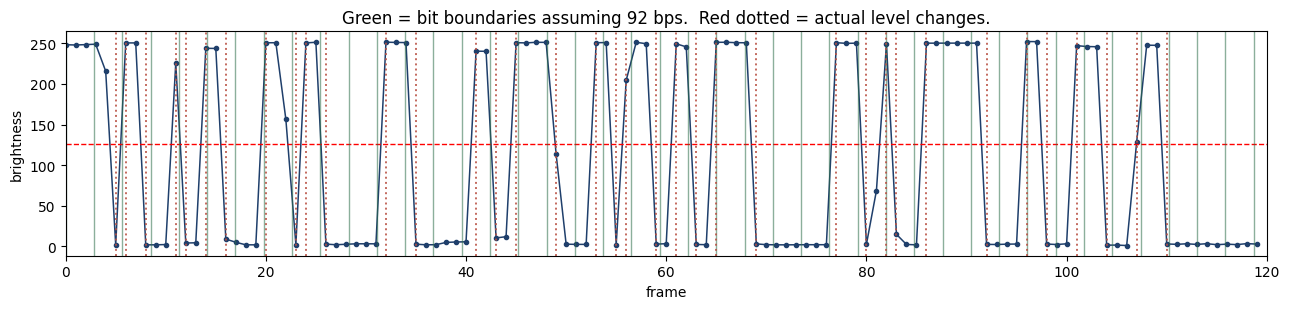

In [2]:
fig, ax = plt.subplots(figsize=(13, 3.2))
seg = 120
ax.plot(np.arange(seg), s[:seg], '-o', ms=3, lw=1.1, color='#1f3f6b')
ax.axhline(thr, color='r', ls='--', lw=1)
for k in np.arange(0, seg, T92):
    ax.axvline(k, color='#2C6E49', alpha=.55, lw=1)
for x in e[e < seg]:
    ax.axvline(x, color='#B85042', alpha=.85, lw=1.4, ls=':')
ax.set_title('Green = bit boundaries assuming 92 bps.  Red dotted = actual level changes.')
ax.set_xlabel('frame'); ax.set_ylabel('brightness'); ax.set_xlim(0, seg)
plt.tight_layout(); plt.show()

Some red lines land on green ones. Many do not. That is the whole problem, and the rest
of this notebook is about measuring it rather than eyeballing it.

## 2. Method A — long baselines

Day 10's estimators failed because a level change is only timed to the nearest frame, which
is about a fifth of a bit.

But that error does **not** grow with distance. The gap between two changes 500 frames
apart is still known to about one frame, so it pins the period roughly 500 times more
tightly. That is the idea here: measure gaps between distant changes, not neighbouring ones.

A correct period makes every long gap land close to a whole number of periods. A wrong one
scores about 0.25 — no better than chance.

In [3]:
def long_baseline(edges, Ts, spans=(20, 50, 100, 200)):
    cost = np.zeros(len(Ts)); used = 0
    for m in spans:
        if len(edges) <= m: continue
        gaps = (edges[m:] - edges[:-m]).astype(float)
        q = gaps[None, :] / Ts[:, None]
        cost += np.mean(np.abs(q - np.round(q)), axis=1); used += 1
    return cost / used

Ts = np.arange(1.20, 6.0, 0.002)
cost = long_baseline(e, Ts)

print("best-scoring periods   (0.25 = no better than chance):")
seen = []
for i in np.argsort(cost):
    if any(abs(Ts[i]-t) < 0.03 for t in seen): continue
    seen.append(Ts[i])
    print(f"   {Ts[i]:.4f} frames -> {FPS/Ts[i]:7.2f} bps    score {cost[i]:.4f}")
    if len(seen) == 6: break
print(f"\n   score at the filename's 92 bps: {cost[np.argmin(np.abs(Ts-T92))]:.4f}")

best-scoring periods   (0.25 = no better than chance):
   1.5000 frames ->  173.33 bps    score 0.2127
   3.0000 frames ->   86.67 bps    score 0.2127
   5.0920 frames ->   51.06 bps    score 0.2143
   1.9640 frames ->  132.38 bps    score 0.2205
   1.2440 frames ->  209.00 bps    score 0.2213
   2.0380 frames ->  127.58 bps    score 0.2228

   score at the filename's 92 bps: 0.2549


**Method A fails.** Every score sits near 0.21 against a chance level of 0.25. Nothing
stands out. And when the same estimator is run on all ten signals it disagrees with itself
— some lamps "prefer" 1.5 frames, others 5.09 — which is what an estimator with no real
signal does.

In [4]:
Ts_c = np.arange(1.20, 6.0, 0.005)
for meta in sorted(Path('signal_v1').glob('*/meta.json')):
    m = json.load(open(meta))
    for sig in m['signals']:
        a = np.load(meta.parent / sig['file'])
        ed, _ = transitions(a)
        c = long_baseline(ed, Ts_c)
        T = Ts_c[np.argmin(c)]
        print(f"   {m['video']['id'].replace('_92bps',''):6s} lamp{sig['lamp']}  "
              f"best {T:.3f} frames = {FPS/T:7.2f} bps   (score {c.min():.4f})")

   1LED   lamp1  best 1.500 frames =  173.33 bps   (score 0.2127)
   2LEDs  lamp1  best 5.095 frames =   51.03 bps   (score 0.2112)


   2LEDs  lamp2  best 5.095 frames =   51.03 bps   (score 0.2107)
   3LEDs  lamp1  best 1.500 frames =  173.33 bps   (score 0.2143)
   3LEDs  lamp2  best 5.090 frames =   51.08 bps   (score 0.2094)
   3LEDs  lamp3  best 5.090 frames =   51.08 bps   (score 0.2102)


   4LEDs  lamp1  best 1.500 frames =  173.33 bps   (score 0.2114)
   4LEDs  lamp2  best 1.500 frames =  173.33 bps   (score 0.2127)
   4LEDs  lamp3  best 5.095 frames =   51.03 bps   (score 0.2138)
   4LEDs  lamp4  best 5.090 frames =   51.08 bps   (score 0.2128)


## 3. Method B — do the changes sit on *any* regular grid?

Step back from "is it 92 bps" and ask a weaker question: is there **any** period whose grid
the level changes respect?

For a candidate period we find the best phase, then measure the average distance from each
change to its nearest boundary. Two reference points make the number readable:

- **No structure at all:** changes scattered anywhere give an average of one quarter of the
  period.
- **A real clock:** changes timed to the nearest frame would average about a quarter of a
  frame — roughly 50% better than the no-structure case.

We plot how far each candidate beats the no-structure case.

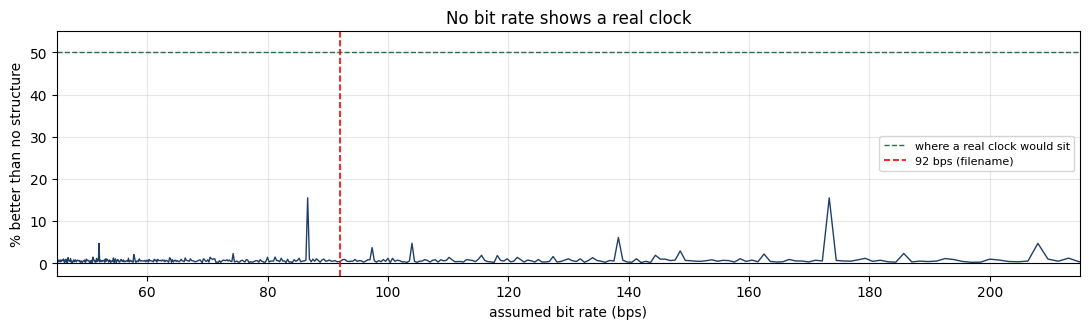

at 92 bps      : 0.3% better than no structure
best anywhere  : 15.5% at 173.3 bps
median         : 0.5%


In [5]:
def grid_score(edges, T, phase_steps=40):
    best = 1e9
    for ph in np.linspace(0, T, phase_steps, endpoint=False):
        r = (edges - ph) / T
        best = min(best, float(np.mean(np.abs(r - np.round(r))) * T))
    return best

Tg  = np.arange(1.2, 6.0, 0.01)
obs = np.array([grid_score(e, T) for T in Tg])
chance = Tg / 4.0
better = (chance - obs) / chance * 100

plt.figure(figsize=(11, 3.4))
plt.plot(FPS/Tg, better, lw=1, color='#1f3f6b')
plt.axhline(0, color='k', lw=.8)
plt.axhline(50, color='#2C6E49', ls='--', lw=1, label='where a real clock would sit')
plt.axvline(BPS, color='r', ls='--', lw=1.2, label='92 bps (filename)')
plt.xlabel('assumed bit rate (bps)'); plt.ylabel('% better than no structure')
plt.title('No bit rate shows a real clock')
plt.xlim(45, 215); plt.ylim(-3, 55); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

i92 = int(np.argmin(np.abs(FPS/Tg - BPS)))
print(f"at 92 bps      : {better[i92]:.1f}% better than no structure")
print(f"best anywhere  : {better.max():.1f}% at {FPS/Tg[np.argmax(better)]:.1f} bps")
print(f"median         : {np.median(better):.1f}%")

**Method B fails too, and this is the strongest evidence in the notebook.**

At 92 bps the level changes beat the no-structure case by **0.3%** (the 0.5% printed above
is the median over all rates). Randomly scattered times would score the same. There is no 92 bps clock in this signal.

Nothing else scores either. The one bump, near 173 bps, is at exactly 1.500 frames — a
period where every second boundary lands on a whole frame number, so integer frame times
fit it by arithmetic rather than by physics. It is an artefact of the frame grid, not a
clock.

A direct way to see it: compare the observed distances against times drawn at random.

distance from the nearest 92 bps boundary:
   observed changes : mean 0.703 frames, 64.0% further than half a frame
   random times     : mean 0.705 frames, 64.3% further than half a frame

A real edge can only be out by half a frame - that is all the rounding allows.


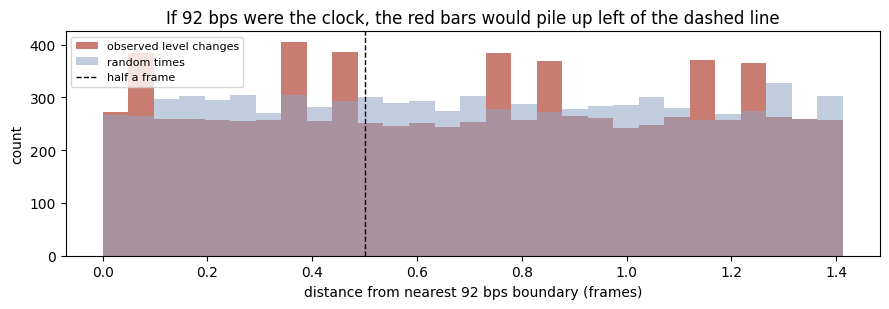

In [6]:
rng = np.random.default_rng(0)
def dists(times, T, ph):
    r = (times - ph) / T
    return np.abs(r - np.round(r)) * T

ph_best = min(np.linspace(0, T92, 200, endpoint=False),
              key=lambda p: dists(e, T92, p).mean())
d_obs  = dists(e, T92, ph_best)
d_rand = dists(rng.uniform(0, len(s), len(e)), T92, ph_best)

print(f"distance from the nearest 92 bps boundary:")
print(f"   observed changes : mean {d_obs.mean():.3f} frames, "
      f"{np.mean(d_obs > 0.5)*100:.1f}% further than half a frame")
print(f"   random times     : mean {d_rand.mean():.3f} frames, "
      f"{np.mean(d_rand > 0.5)*100:.1f}% further than half a frame")
print("\nA real edge can only be out by half a frame - that is all the rounding allows.")

plt.figure(figsize=(9, 3.2))
bins = np.linspace(0, T92/2, 30)
plt.hist(d_obs,  bins=bins, alpha=.75, color='#B85042', label='observed level changes')
plt.hist(d_rand, bins=bins, alpha=.55, color='#8FA3C4', label='random times')
plt.axvline(0.5, color='k', ls='--', lw=1, label='half a frame')
plt.xlabel('distance from nearest 92 bps boundary (frames)'); plt.ylabel('count')
plt.title('If 92 bps were the clock, the red bars would pile up left of the dashed line')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 4. Method C — fit the period to the run lengths

A different angle that does not depend on timing individual changes.

How long the lamp holds one level is a property of the period. We build a small model of
what the camera would record from random bits at a given period, and compare its run
lengths against the real ones.

The model also needs the **exposure time**. If the shutter were open for the whole frame,
about 18% of frames would land part-way between on and off. Only 5% do, so the exposure
must be much shorter. Both are fitted together.

In [7]:
lo, hi = np.percentile(s, 10), np.percentile(s, 90)
obs_runs = np.diff(np.flatnonzero(np.diff((s > thr).astype(np.int8))))
K = 10
obs_h  = np.bincount(np.clip(obs_runs, 0, K), minlength=K+1)[1:K+1] / len(obs_runs)
obs_mid = float(np.mean((s > lo + .2*(hi-lo)) & (s < hi - .2*(hi-lo))))
print(f"observed: mean run {obs_runs.mean():.2f} frames, "
      f"{obs_mid*100:.2f}% of frames part-way between on and off")

sim_rng = np.random.default_rng(0)
def simulate(T, duty, N=20000):
    nb = int(N/T) + 8
    bits = sim_rng.integers(0, 2, nb).astype(float)
    fr = np.empty(N); mid = 0
    for n in range(N):
        a, b = n, n + duty                     # the exposure window
        k0, k1 = int(a // T), int(min(b // T, nb-1))
        tot = 0.0
        for k in range(k0, k1+1):
            l, h = max(a, k*T), min(b, (k+1)*T)
            if h > l: tot += bits[k] * (h - l)
        v = tot / duty; fr[n] = v
        if 0.2 < v < 0.8: mid += 1
    r = np.diff(np.flatnonzero(np.diff((fr > 0.5).astype(np.int8))))
    if len(r) < 50: return None, None, None
    return np.bincount(np.clip(r,0,K), minlength=K+1)[1:K+1]/len(r), r.mean(), mid/N

rows = []
for T in np.arange(1.2, 3.6, 0.1):
    for duty in (0.3, 0.6, 1.0):
        h, mr, mid = simulate(T, duty)
        if h is None: continue
        misfit = float(np.sum((h-obs_h)**2 / (h+obs_h+1e-9))) + 30*abs(mid-obs_mid)
        rows.append((misfit, T, duty, mr, mid))
rows.sort()
print(f"\n{'period':>8s} {'bps':>8s} {'exposure':>9s} {'mean run':>9s} {'% mid':>7s} {'misfit':>8s}")
for mf, T, du, mr, mid in rows[:6]:
    print(f"{T:8.2f} {FPS/T:8.1f} {du:9.0%} {mr:9.2f} {mid*100:7.2f} {mf:8.4f}")

observed: mean run 3.36 frames, 5.06% of frames part-way between on and off



  period      bps  exposure  mean run   % mid   misfit
    1.90    136.8       30%      3.79    5.27   0.1625
    1.80    144.4       30%      3.62    5.56   0.1896
    2.10    123.8       30%      4.16    4.75   0.2822
    2.20    118.2       30%      4.37    4.55   0.3310
    1.70    152.9       30%      3.39    5.94   0.3375
    1.60    162.5       30%      3.17    6.33   0.4871


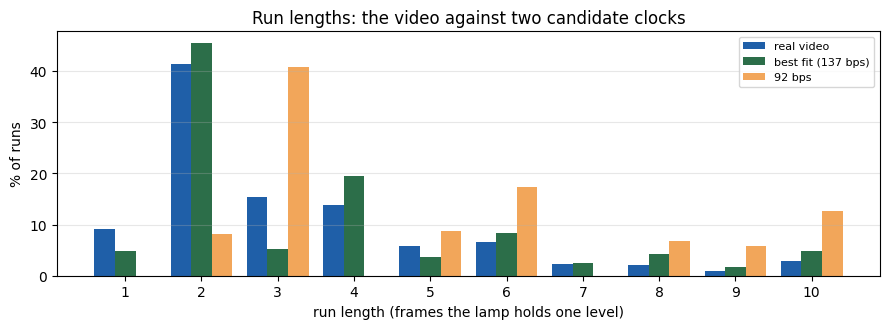

In [8]:
h_best, _, _ = simulate(rows[0][1], rows[0][2])
h_92,  _, _ = simulate(T92, rows[0][2])
x = np.arange(1, K+1); w = 0.27
plt.figure(figsize=(9, 3.4))
plt.bar(x - w, obs_h*100,  w, label='real video',                   color='#1f5fa8')
plt.bar(x,     h_best*100, w, label=f'best fit ({FPS/rows[0][1]:.0f} bps)', color='#2C6E49')
plt.bar(x + w, h_92*100,   w, label='92 bps',                       color='#F2A65A')
plt.xlabel('run length (frames the lamp holds one level)'); plt.ylabel('% of runs')
plt.title('Run lengths: the video against two candidate clocks')
plt.xticks(x); plt.legend(fontsize=8); plt.grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

**Method C gives an answer, but not a trustworthy one.** The best fit is a period near
1.9 frames — about 137 bps — with a short exposure.

The important part is not that number. It is the orange bars: at 92 bps the model produces
**zero** runs of 1, 4 or 7 frames, because they are arithmetically impossible at that
period. The real video has 9% at 1 frame and 14% at 4 frames. Day 10 already showed
hysteresis does not remove them, so they are not threshold noise.

The fitted 137 bps should be read as "shorter than 2.826 frames", not as a measurement.
Method B says no period has real clock structure, so Method C is fitting a shape, not
finding a clock.

## 5. Candidate bit boundaries

Despite all of the above, the later stages need *something* to work with. So we define
candidate boundaries explicitly as an **assumption**, not a finding.

**Candidate 1 (default):** 92 bps from the filename, period 2.826 frames, phase chosen by
the widest separation between the on and off groups.

In [9]:
def best_phase(sig, T):
    """Pick the phase where the sampled values sit furthest from the threshold."""
    th = (np.percentile(sig,10) + np.percentile(sig,90)) / 2
    best = None
    for ph in np.arange(0, T, 0.02):
        centres = np.arange(ph + T/2, len(sig)-1, T)
        v = sig[np.round(centres).astype(int)]
        score = float(np.mean(np.abs(v - th)))
        if best is None or score > best[0]: best = (score, ph)
    return best[1], best[0]

candidates = {}
for meta in sorted(Path('signal_v1').glob('*/meta.json')):
    m = json.load(open(meta))
    for sig in m['signals']:
        a = np.load(meta.parent / sig['file'])
        ph, sc = best_phase(a, T92)
        key = f"{m['video']['id']}/lamp{sig['lamp']}"
        candidates[key] = {'period_frames': round(T92, 4), 'bits_per_second': BPS,
                           'phase_frames': round(float(ph), 3),
                           'n_bits': int((len(a) - ph) // T92),
                           'eye_score': round(sc, 2),
                           'basis': 'ASSUMED from filename; not confirmed by the signal'}
        print(f"{key:26s} phase {ph:5.2f} frames  ->  {candidates[key]['n_bits']:6d} candidate bits")

json.dump(candidates, open('candidate_timing.json','w'), indent=2)
print("\nwritten to candidate_timing.json")

1LED_92bps/lamp1           phase  2.44 frames  ->    9855 candidate bits
2LEDs_92bps/lamp1          phase  1.54 frames  ->    6083 candidate bits
2LEDs_92bps/lamp2          phase  1.32 frames  ->    6083 candidate bits
3LEDs_92bps/lamp1          phase  2.66 frames  ->    4056 candidate bits
3LEDs_92bps/lamp2          phase  2.36 frames  ->    4056 candidate bits
3LEDs_92bps/lamp3          phase  2.70 frames  ->    4056 candidate bits
4LEDs_92bps/lamp1          phase  1.10 frames  ->    3045 candidate bits
4LEDs_92bps/lamp2          phase  1.28 frames  ->    3045 candidate bits
4LEDs_92bps/lamp3          phase  2.80 frames  ->    3045 candidate bits
4LEDs_92bps/lamp4          phase  2.40 frames  ->    3045 candidate bits

written to candidate_timing.json


## 6. Uncertainty and the alternatives

What we know, and what we are guessing.

| | Status |
|---|---|
| Frame rate 260 fps | **Confirmed.** Header, and frames divided by duration, agree. No duplicated frames |
| Frames evenly spaced in time | **Confirmed.** Timing jitter 0.009% |
| The signal is cleanly two-level | **Confirmed.** Gap of about 245 against noise of 6 to 11 |
| Bit rate 92 bps | **Not confirmed, and the evidence is against it** |
| Bit boundaries | **Assumed**, from the filename |

### Four explanations, none yet ruled out

**H1 — the rate is not 92 bps.** Fits the run lengths (Method C prefers about 137 bps) and
the excess level changes. Against it: Method B finds no clock at *any* rate, so this only
moves the problem.

**H2 — the light switches faster than the camera can follow.** If the true period is under
two frames, what we record is aliasing, and the level changes we see are not the real
edges. This explains everything at once: no clock at any period, impossible run lengths,
and more changes than 92 bps allows. It also predicts that reliable decoding is impossible
from these videos. Worth noting the videos were shot at 260 fps, which suggests someone
deliberately chose a high frame rate — so this would be an unlucky outcome, not an obvious
one.

**H3 — a line code or carrier sits on top of the data.** Our own Day 02 review describes
this as normal practice in this field: the lamp is driven with a fast flicker-free carrier
and the data rides on it. Then 92 bps is the payload rate and the light switches faster.
Consistent with everything measured. A Manchester test came back at 47% against the 100%
Manchester requires, so it is not that particular code.

**H4 — our level-change detection is wrong.** Largely ruled out. Hysteresis up to 35% of
the signal range changes nothing, and all ten signals behave the same way.

H2 and H3 both say the same thing in practice: **the light is switching faster than 92
times a second**, and the filename refers to something other than the raw switching rate.

### What would settle it

| Answer needed | What it would settle |
|---|---|
| The transmitted bits for one video | Everything. We could test any candidate clock directly |
| Is 92 bps the payload rate or the light's switching rate? | H2 versus H3 |
| Any preamble, line code or carrier | H3 |
| The camera's exposure time | Method C's fit; we inferred about 30% of a frame |

## 7. What this notebook delivers

**Delivered**

- `candidate_timing.json` — a period and phase for all ten signals, labelled as an
  assumption from the filename
- Sync markers drawn over the signal, so the mismatch is visible rather than argued
- Three independent estimators, with their results and their failure modes
- A measured statement that no clock is recoverable: 0.3% better than no structure at all
  at 92 bps (median 0.5% across all rates from 45 to 215 bps)

**Not delivered, and it cannot be from this data**

- A confirmed symbol clock
- Bit boundaries anyone should trust

**Recommendation.** Do not build the decoder on the 92 bps assumption until Q1 to Q3 come
back. The candidate timing is here so the decoder can be *written* and tested end to end,
but any bits it produces are unverified, and the eye-opening score it reports measures
confidence, never correctness.